In [1]:
# Nếu chạy trên Kaggle/Colab, chạy cell này trước.
!pip install -q -U "transformers" "accelerate" "bitsandbytes>=0.46.1" "sentencepiece" yt-dlp youtube-transcript-api pandas matplotlib

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 182.3/182.3 kB 10.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 5.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.8/52.8 kB 3.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.6/10.6 MB 101.5 MB/s eta 0:00:0000:010:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 383.7/383.7 kB 25.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 31.8 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 74.2 MB/s eta 0:00:00:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 485.2/485.2 kB 26.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 105.2 MB/s eta 0:00:0000:010:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.8/8.8 MB 93.9 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 663.6/663.6 kB 27.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.5/4.5 MB 79.3 MB/s eta 0:00:00:

In [2]:
import os
import re
import html
import json
import time
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import torch.nn.functional as F
import yt_dlp

from IPython.display import display, Markdown
from transformers import AutoTokenizer, AutoModel, AutoModelForCausalLM, BitsAndBytesConfig
from youtube_transcript_api import YouTubeTranscriptApi
from youtube_transcript_api._errors import NoTranscriptFound, TranscriptsDisabled, VideoUnavailable

BASE_DIR = Path(".")
DATA_DIR = BASE_DIR / "demo_data"
OUTPUT_DIR = BASE_DIR / "demo_outputs"
SUB_DIR = DATA_DIR / "subtitles"
META_DIR = DATA_DIR / "metadata"

for p in [DATA_DIR, OUTPUT_DIR, SUB_DIR, META_DIR]:
    p.mkdir(parents=True, exist_ok=True)

PHOBERT_MODEL = "vinai/phobert-base"
SUMMARY_MODEL = "Qwen/Qwen2.5-7B-Instruct"
QA_MODEL = "Qwen/Qwen3-4B-Instruct-2507"
BLOCK_SIZE = 60
TOPIC_SHIFT_THRESHOLD = 0.90
TOP_K = 5

device = "cuda" if torch.cuda.is_available() else "cpu"
print("CUDA available:", torch.cuda.is_available())
print("Device:", device)
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

CUDA available: True
Device: cuda
GPU: Tesla T4


## 1. Nhập link YouTube

In [3]:
youtube_url = input("Nhập link YouTube: ").strip()
if not youtube_url:
    youtube_url = "https://youtu.be/ut7-CUa3f9s?si=nQtCxoCmO_j-aaPs"
print("YouTube URL:", youtube_url)

Nhập link YouTube:  https://youtu.be/ut7-CUa3f9s?si=nQtCxoCmO_j-aaPs


YouTube URL: https://youtu.be/ut7-CUa3f9s?si=nQtCxoCmO_j-aaPs


## 2. Hàm lấy metadata và phụ đề

In [ ]:
def get_youtube_metadata(url: str) -> dict:
    ydl_opts = {
        "quiet": True,
        "skip_download": True,
        "ignoreerrors": True,
    }
    with yt_dlp.YoutubeDL(ydl_opts) as ydl:
        info = ydl.extract_info(url, download=False)
    if not info:
        raise ValueError("Không lấy được metadata video.")

    metadata = {
        "video_id": info.get("id"),
        "youtube_url": url,
        "title": info.get("title"),
        "description": info.get("description"),
        "tags": info.get("tags", []),
        "total_duration": info.get("duration"),
        "channel_name": info.get("channel"),
        "channel_id": info.get("channel_id"),
        "uploader": info.get("uploader"),
        "view_count": info.get("view_count"),
        "like_count": info.get("like_count"),
        "comment_count": info.get("comment_count"),
        "published_at": info.get("upload_date"),
        "thumbnail": info.get("thumbnail"),
        "webpage_url": info.get("webpage_url"),
    }

    if metadata["published_at"] and len(metadata["published_at"]) == 8:
        d = metadata["published_at"]
        metadata["published_at"] = f"{d[:4]}-{d[4:6]}-{d[6:]}"
    return metadata


def clean_segment_text(text: str) -> str:
    if text is None:
        return ""
    text = html.unescape(text)
    text = re.sub(r"<[^>]+>", " ", text)
    noise_patterns = [
        r"\[music\]", r"\[applause\]", r"\[laughter\]", r"\[sound\]", r"\[noise\]",
        r"\(music\)", r"\(applause\)", r"\(laughter\)",
    ]
    for pattern in noise_patterns:
        text = re.sub(pattern, " ", text, flags=re.IGNORECASE)
    text = text.replace("\n", " ")
    return re.sub(r"\s+", " ", text).strip()


def normalize_transcript(items):
    segments = []
    for item in items:
        if isinstance(item, dict):
            start = item.get("start", 0)
            duration = item.get("duration", 0)
            text = item.get("text", "")
        else:
            start = getattr(item, "start", 0)
            duration = getattr(item, "duration", 0)
            text = getattr(item, "text", "")

        start = float(start)
        duration = float(duration)
        end = start + duration
        text = clean_segment_text(text)
        if text:
            segments.append({
                "start": round(start, 3),
                "duration": round(duration, 3),
                "end": round(end, 3),
                "text": text,
            })
    return segments


def download_vi_subtitle(video_id: str):
    api = YouTubeTranscriptApi()
    try:
        transcript_list = api.list(video_id)
        print("Danh sách phụ đề có sẵn:")
        for transcript in transcript_list:
            print("-", transcript.language_code, "|", transcript.language, "| generated:", transcript.is_generated)

        vi_transcript = transcript_list.find_transcript(["vi"])
        return normalize_transcript(vi_transcript.fetch())

    except NoTranscriptFound:
        print("Không tìm thấy phụ đề tiếng Việt cho video này.")
    except TranscriptsDisabled:
        print("Video này đã tắt phụ đề.")
    except VideoUnavailable:
        print("Video không khả dụng.")
    except Exception as e:
        print("Lỗi khi tải phụ đề:", e)
    return None

In [5]:
metadata = get_youtube_metadata(youtube_url)
video_id = metadata["video_id"]

metadata_path = META_DIR / f"{video_id}_metadata.json"
with open(metadata_path, "w", encoding="utf-8") as f:
    json.dump(metadata, f, ensure_ascii=False, indent=2)

segments = download_vi_subtitle(video_id)
if not segments:
    raise RuntimeError("Không có phụ đề tiếng Việt. Hãy chọn video khác hoặc thêm Whisper fallback.")

subtitle_data = {
    "video_id": video_id,
    "language": "vi",
    "total_segments": len(segments),
    "segments": segments,
}
subtitle_path = SUB_DIR / f"{video_id}_vi.json"
with open(subtitle_path, "w", encoding="utf-8") as f:
    json.dump(subtitle_data, f, ensure_ascii=False, indent=2)

print("Video ID:", video_id)
print("Title:", metadata["title"])
print("Saved metadata:", metadata_path)
print("Saved subtitle:", subtitle_path)
print("Total subtitle segments:", len(segments))

Danh sách phụ đề có sẵn:
- vi | Vietnamese (auto-generated) | generated: True
Video ID: ut7-CUa3f9s
Title: NLP - Reinforcement Learning - TS. Đặng Thị Phúc
Saved metadata: demo_data/metadata/ut7-CUa3f9s_metadata.json
Saved subtitle: demo_data/subtitles/ut7-CUa3f9s_vi.json
Total subtitle segments: 1587


## 3. Chia transcript thành block 60 giây

In [6]:
def format_time(seconds):
    seconds = int(seconds)
    h = seconds // 3600
    m = (seconds % 3600) // 60
    s = seconds % 60
    if h > 0:
        return f"{h:02d}:{m:02d}:{s:02d}"
    return f"{m:02d}:{s:02d}"


def split_transcript_to_blocks(transcript, block_size=60):
    blocks = []
    current_block = None

    for item in transcript:
        start = float(item["start"])
        end = float(item.get("end", start + float(item.get("duration", 0))))
        text = item.get("text", "").strip()
        if not text:
            continue

        block_id = int(start // block_size)
        if current_block is None:
            current_block = {
                "block_id": block_id,
                "start_time": block_id * block_size,
                "end_time": (block_id + 1) * block_size,
                "texts": [],
            }

        if block_id != current_block["block_id"]:
            current_block["text"] = " ".join(current_block["texts"])
            del current_block["texts"]
            blocks.append(current_block)

            current_block = {
                "block_id": block_id,
                "start_time": block_id * block_size,
                "end_time": (block_id + 1) * block_size,
                "texts": [],
            }

        current_block["texts"].append(text)

    if current_block is not None and current_block["texts"]:
        current_block["text"] = " ".join(current_block["texts"])
        del current_block["texts"]
        blocks.append(current_block)

    return blocks


blocks = split_transcript_to_blocks(segments, block_size=BLOCK_SIZE)
print("Total blocks:", len(blocks))

Total blocks: 87


In [7]:
blocks_preview = pd.DataFrame([
    {
        "block_id": b["block_id"],
        "timestamp": f'{format_time(b["start_time"])} - {format_time(b["end_time"])}',
        "text_preview": b["text"][:300],
        "chars": len(b["text"]),
    }
    for b in blocks
])
display(blocks_preview)

with open(OUTPUT_DIR / "blocks_raw.json", "w", encoding="utf-8") as f:
    json.dump(blocks, f, ensure_ascii=False, indent=2)

,block_id,timestamp,text_preview,chars
0,3,03:00 - 04:00,Rồi chào các bạn. Thấy imắn quá ha. À hôm nay ...,236
1,4,04:00 - 05:00,à thì các bạn thấy tiếp cận với các cái a các ...,630
2,5,05:00 - 06:00,mình sẽ tạo một cái bộ dữ liệu bên đây là X à ...,743
3,6,06:00 - 07:00,không? Thì với cái nguyên tắc làm việc này thì...,799
4,7,07:00 - 08:00,điểm bất lợi của cái mô hình tạo sinh văn bản ...,829
...,...,...,...,...
82,92,01:32:00 - 01:33:00,đi tiếp hoặc em lỡ miệng nói một câu gì mà Huy...,796
83,93,01:33:00 - 01:34:00,nó tiếp cận khá là giống với cái cách con ngườ...,295
84,96,01:36:00 - 01:37:00,Луцені,6
85,111,01:51:00 - 01:52:00,Cô ơi,5


## 4. Load PhoBERT và tạo embedding cho block

In [8]:
tokenizer = AutoTokenizer.from_pretrained(PHOBERT_MODEL)
phobert = AutoModel.from_pretrained(PHOBERT_MODEL).to(device)
phobert.eval()
print("Loaded:", PHOBERT_MODEL)

config.json:   0%|          | 0.00/557 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

bpe.codes: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/543M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/543M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] RobertaModel LOAD REPORT from: vinai/phobert-base
Key                       | Status     |  | 
--------------------------+------------+--+-
lm_head.bias              | UNEXPECTED |  | 
lm_head.dense.bias        | UNEXPECTED |  | 
lm_head.dense.weight      | UNEXPECTED |  | 
lm_head.decoder.bias      | UNEXPECTED |  | 
lm_head.layer_norm.weight | UNEXPECTED |  | 
lm_head.layer_norm.bias   | UNEXPECTED |  | 
lm_head.decoder.weight    | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loaded: vinai/phobert-base


In [9]:
def mean_pooling(model_output, attention_mask):
    token_embeddings = model_output.last_hidden_state
    input_mask_expanded = attention_mask.unsqueeze(-1).expand(token_embeddings.size()).float()
    sum_embeddings = torch.sum(token_embeddings * input_mask_expanded, dim=1)
    sum_mask = torch.clamp(input_mask_expanded.sum(dim=1), min=1e-9)
    return sum_embeddings / sum_mask


@torch.no_grad()
def get_phobert_embedding(text, max_length=256):
    inputs = tokenizer(
        text,
        padding=True,
        truncation=True,
        max_length=max_length,
        return_tensors="pt",
    )
    inputs = {k: v.to(device) for k, v in inputs.items()}
    outputs = phobert(**inputs)
    embedding = mean_pooling(outputs, inputs["attention_mask"])
    embedding = F.normalize(embedding, p=2, dim=1)
    return embedding.cpu().numpy()[0]


def embed_blocks_with_phobert(blocks):
    for i, block in enumerate(blocks):
        block["embedding_model"] = PHOBERT_MODEL
        block["embedding"] = get_phobert_embedding(block["text"]).tolist()
        if (i + 1) % 5 == 0 or i == len(blocks) - 1:
            print(f"Embedded {i + 1}/{len(blocks)} blocks")
    return blocks


blocks = embed_blocks_with_phobert(blocks)

Embedded 5/87 blocks
Embedded 10/87 blocks
Embedded 15/87 blocks
Embedded 20/87 blocks
Embedded 25/87 blocks
Embedded 30/87 blocks
Embedded 35/87 blocks
Embedded 40/87 blocks
Embedded 45/87 blocks
Embedded 50/87 blocks
Embedded 55/87 blocks
Embedded 60/87 blocks
Embedded 65/87 blocks
Embedded 70/87 blocks
Embedded 75/87 blocks
Embedded 80/87 blocks
Embedded 85/87 blocks
Embedded 87/87 blocks


## 5. Tính độ tương đồng và gộp block thành topic

In [10]:
def cosine_similarity(vec_a, vec_b):
    a = np.array(vec_a)
    b = np.array(vec_b)
    return float(np.dot(a, b) / (np.linalg.norm(a) * np.linalg.norm(b) + 1e-9))


def compute_adjacent_similarity(blocks):
    for i in range(len(blocks) - 1):
        sim = cosine_similarity(blocks[i]["embedding"], blocks[i + 1]["embedding"])
        blocks[i]["next_similarity"] = sim
    if blocks:
        blocks[-1]["next_similarity"] = None
    return blocks


def detect_topic_shift(blocks, threshold=0.90):
    for i in range(len(blocks) - 1):
        sim = blocks[i]["next_similarity"]
        blocks[i]["topic_shift_after"] = sim is not None and sim < threshold
    if blocks:
        blocks[-1]["topic_shift_after"] = True
    return blocks


def merge_blocks_to_topics(blocks):
    topics = []
    topic_id = 0
    current_topic = {
        "topic_id": topic_id,
        "start_time": None,
        "end_time": None,
        "block_ids": [],
        "texts": [],
    }

    for block in blocks:
        if current_topic["start_time"] is None:
            current_topic["start_time"] = block["start_time"]
        current_topic["end_time"] = block["end_time"]
        current_topic["block_ids"].append(block["block_id"])
        current_topic["texts"].append(block["text"])

        if block.get("topic_shift_after", False):
            current_topic["text"] = " ".join(current_topic["texts"])
            del current_topic["texts"]
            topics.append(current_topic)

            topic_id += 1
            current_topic = {
                "topic_id": topic_id,
                "start_time": None,
                "end_time": None,
                "block_ids": [],
                "texts": [],
            }
    return topics


blocks = compute_adjacent_similarity(blocks)
blocks = detect_topic_shift(blocks, threshold=TOPIC_SHIFT_THRESHOLD)
topics = merge_blocks_to_topics(blocks)

print("Total topics:", len(topics))

Total topics: 28


In [11]:
block_table = pd.DataFrame([
    {
        "block_id": b["block_id"],
        "timestamp": f'{format_time(b["start_time"])} - {format_time(b["end_time"])}',
        "next_similarity": b["next_similarity"],
        "topic_shift_after": b["topic_shift_after"],
        "text_preview": b["text"][:220],
    }
    for b in blocks
])
display(block_table)

topic_table = pd.DataFrame([
    {
        "topic_id": t["topic_id"],
        "timestamp": f'{format_time(t["start_time"])} - {format_time(t["end_time"])}',
        "block_ids": t["block_ids"],
        "text_preview": t["text"][:350],
        "chars": len(t["text"]),
    }
    for t in topics
])
display(topic_table)

with open(OUTPUT_DIR / "blocks_phobert.json", "w", encoding="utf-8") as f:
    json.dump(blocks, f, ensure_ascii=False, indent=2)

with open(OUTPUT_DIR / "topics_phobert.json", "w", encoding="utf-8") as f:
    json.dump(topics, f, ensure_ascii=False, indent=2)

,block_id,timestamp,next_similarity,topic_shift_after,text_preview
0,3,03:00 - 04:00,0.880344,True,Rồi chào các bạn. Thấy imắn quá ha. À hôm nay ...
1,4,04:00 - 05:00,0.937025,False,à thì các bạn thấy tiếp cận với các cái a các ...
2,5,05:00 - 06:00,0.938691,False,mình sẽ tạo một cái bộ dữ liệu bên đây là X à ...
3,6,06:00 - 07:00,0.943416,False,không? Thì với cái nguyên tắc làm việc này thì...
4,7,07:00 - 08:00,0.927202,False,điểm bất lợi của cái mô hình tạo sinh văn bản ...
...,...,...,...,...,...
82,92,01:32:00 - 01:33:00,0.864494,True,đi tiếp hoặc em lỡ miệng nói một câu gì mà Huy...
83,93,01:33:00 - 01:34:00,0.243915,True,nó tiếp cận khá là giống với cái cách con ngườ...
84,96,01:36:00 - 01:37:00,0.284156,True,Луцені
85,111,01:51:00 - 01:52:00,0.292628,True,Cô ơi


,topic_id,timestamp,block_ids,text_preview,chars
0,0,03:00 - 04:00,[3],Rồi chào các bạn. Thấy imắn quá ha. À hôm nay ...,236
1,1,04:00 - 20:00,"[4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16,...",à thì các bạn thấy tiếp cận với các cái a các ...,12288
2,2,20:00 - 21:00,[20],mình ứng dụng trong cái lĩnh vực của mình tron...,439
3,3,21:00 - 22:00,[21],chưa tay ơi coi được bao nhiêu bạn coi nhiêu đ...,359
4,4,22:00 - 30:00,"[22, 23, 24, 25, 26, 27, 28, 29]",chứ không ngủ nó quên. Rồi đó là nói sơ về cái...,6181
5,5,30:00 - 31:00,[30],tiên nó sẽ gồm có à ba cái bước ha ba cái bước...,431
6,6,31:00 - 47:00,"[31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 4...",các bạn cũng phải xử lý nó. Tại vì các bạn tự ...,11664
7,7,47:00 - 54:00,"[47, 48, 49, 50, 51, 52, 53]",Thì ở đây á mình sẽ có một cái a vì là nó có q...,5176
8,8,54:00 - 57:00,"[54, 55, 56]",trạng thái này sang trạng thái này á thì em ph...,2439
9,9,57:00 - 01:01:00,"[57, 58, 59, 60]",đúng không? Tức là lúc này cái reward cái chín...,3275


## 6. Trực quan hóa phân bổ từ vựng và độ dài văn bản


,block_id,chars,words,unique_words,lexical_diversity,duration_sec
count,87.00,87.00,87.00,87.0,87.00,87.0
mean,48.32,665.17,158.76,80.3,0.54,60.0
std,28.54,218.92,52.09,22.5,0.12,0.0
min,3.00,5.00,1.00,1.0,0.40,60.0
25%,24.50,625.50,148.00,76.0,0.48,60.0
50%,46.00,749.00,180.00,86.0,0.51,60.0
75%,74.50,799.00,192.00,94.0,0.56,60.0
max,112.00,908.00,216.00,110.0,1.00,60.0


,topic_id,chars,words,unique_words,lexical_diversity,duration_sec
count,28.00,28.00,28.00,28.00,28.00,28.00
mean,13.50,2068.89,493.29,122.68,0.56,186.43
std,8.23,3279.04,789.20,119.26,0.26,247.84
min,0.00,5.00,1.00,1.00,0.14,60.00
25%,6.75,280.25,66.25,48.75,0.32,60.00
50%,13.50,459.50,109.00,70.00,0.61,60.00
75%,20.25,2589.50,608.75,195.50,0.71,195.00
max,27.00,12288.00,2951.00,430.00,1.00,960.00


,word,count
0,cái,837
1,đúng,172
2,câu,165
3,hình,152
4,mà,145
5,mô,144
6,dữ,144
7,liệu,144
8,phải,129
9,ha,96


/tmp/ipykernel_57/1487037119.py:69: UserWarning: Glyph 7873 (\N{LATIN SMALL LETTER E WITH CIRCUMFLEX AND GRAVE}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/tmp/ipykernel_57/1487037119.py:69: UserWarning: Glyph 417 (\N{LATIN SMALL LETTER O WITH HORN}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/tmp/ipykernel_57/1487037119.py:69: UserWarning: Glyph 7899 (\N{LATIN SMALL LETTER O WITH HORN AND ACUTE}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/tmp/ipykernel_57/1487037119.py:69: UserWarning: Glyph 7847 (\N{LATIN SMALL LETTER A WITH CIRCUMFLEX AND GRAVE}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/tmp/ipykernel_57/1487037119.py:69: UserWarning: Glyph 7909 (\N{LATIN SMALL LETTER U WITH DOT BELOW}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/tmp/ipykernel_57/1487037119.py:69: UserWarning: Glyph 7897 (\N{LATIN SMALL LETTER O WITH CIRCUMFLEX AND DOT BELOW}) missing from font(s) Liberation Sans.
  plt.tight_layout(

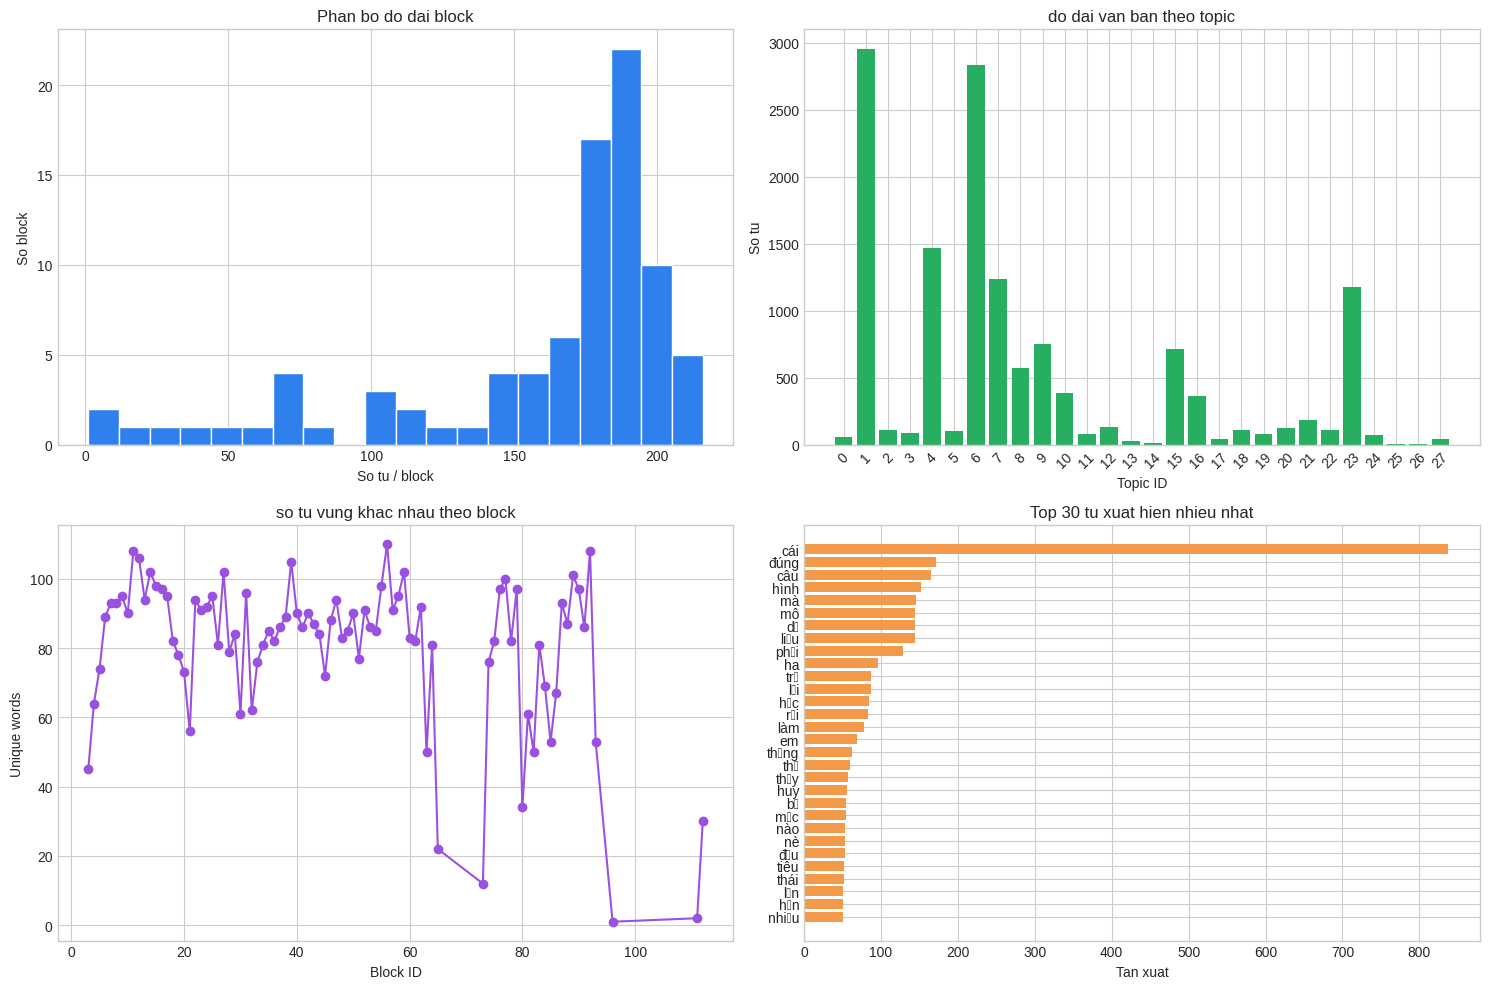

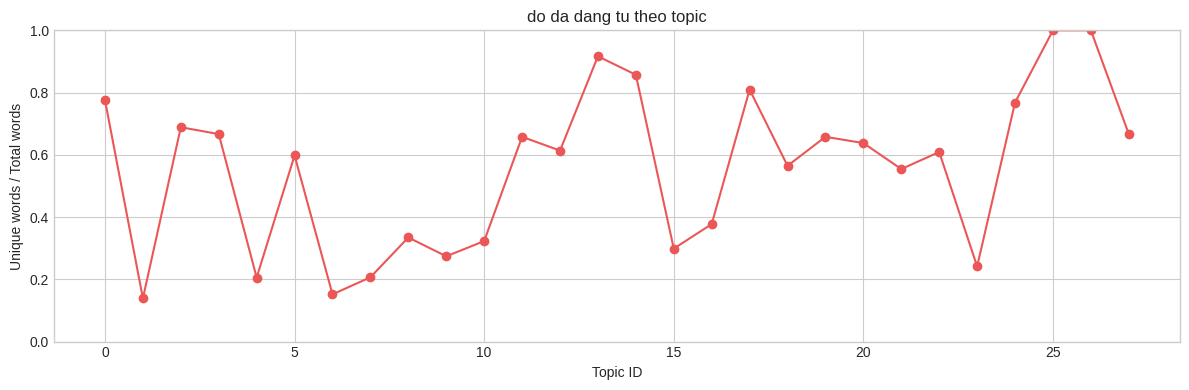

In [12]:
import matplotlib.pyplot as plt
from collections import Counter

VI_STOPWORDS = {
    "và", "là", "của", "có", "cho", "trong", "một", "các", "những", "được",
    "với", "thì", "để", "này", "đó", "khi", "ra", "về", "như", "từ", "ở",
    "trên", "bạn", "mình", "tôi", "chúng", "ta", "sẽ", "đã", "đang", "không",
    "nó", "rất", "cũng", "nên", "hay", "lại", "vì", "nếu", "the", "a", "an",
}

def simple_vietnamese_tokens(text):
    text = str(text).lower()
    return re.findall(r"[a-zA-ZÀ-ỹ0-9_]+", text)

def build_text_stats(items, id_col):
    rows = []
    for item in items:
        text = item.get("text", "")
        tokens = simple_vietnamese_tokens(text)
        unique_tokens = set(tokens)
        rows.append({
            id_col: item.get(id_col),
            "chars": len(text),
            "words": len(tokens),
            "unique_words": len(unique_tokens),
            "lexical_diversity": len(unique_tokens) / len(tokens) if tokens else 0,
            "duration_sec": item.get("end_time", 0) - item.get("start_time", 0),
        })
    return pd.DataFrame(rows)

block_stats = build_text_stats(blocks, "block_id")
topic_stats = build_text_stats(topics, "topic_id")

all_tokens = [
    token
    for block in blocks
    for token in simple_vietnamese_tokens(block.get("text", ""))
    if token not in VI_STOPWORDS and len(token) > 1
]
vocab_counts = pd.DataFrame(Counter(all_tokens).most_common(30), columns=["word", "count"])

display(block_stats.describe().round(2))
display(topic_stats.describe().round(2))
display(vocab_counts.head(20))

plt.style.use("seaborn-v0_8-whitegrid")
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

axes[0, 0].hist(block_stats["words"], bins=20, color="#2f80ed", edgecolor="white")
axes[0, 0].set_title("Phan bo do dai block")
axes[0, 0].set_xlabel("So tu / block")
axes[0, 0].set_ylabel("So block")

axes[0, 1].bar(topic_stats["topic_id"].astype(str), topic_stats["words"], color="#27ae60")
axes[0, 1].set_title("do dai van ban theo topic")
axes[0, 1].set_xlabel("Topic ID")
axes[0, 1].set_ylabel("So tu")
axes[0, 1].tick_params(axis="x", rotation=45)

axes[1, 0].plot(block_stats["block_id"], block_stats["unique_words"], marker="o", linewidth=1.5, color="#9b51e0")
axes[1, 0].set_title("so tu vung khac nhau theo block")
axes[1, 0].set_xlabel("Block ID")
axes[1, 0].set_ylabel("Unique words")

axes[1, 1].barh(vocab_counts["word"].iloc[::-1], vocab_counts["count"].iloc[::-1], color="#f2994a")
axes[1, 1].set_title("Top 30 tu xuat hien nhieu nhat")
axes[1, 1].set_xlabel("Tan xuat")

plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(topic_stats["topic_id"], topic_stats["lexical_diversity"], marker="o", color="#eb5757")
ax.set_title("do da dang tu theo topic")
ax.set_xlabel("Topic ID")
ax.set_ylabel("Unique words / Total words")
ax.set_ylim(0, min(1, topic_stats["lexical_diversity"].max() + 0.1))
plt.tight_layout()
plt.show()

## 7. Load Qwen2.5 để tóm tắt

In [13]:
bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_compute_dtype=torch.float16,
    bnb_4bit_use_double_quant=True,
    bnb_4bit_quant_type="nf4",
)

summary_tokenizer = AutoTokenizer.from_pretrained(SUMMARY_MODEL, trust_remote_code=True)
summary_model = AutoModelForCausalLM.from_pretrained(
    SUMMARY_MODEL,
    quantization_config=bnb_config,
    device_map="auto",
    trust_remote_code=True,
)
summary_model.eval()
print("Loaded summary model:", SUMMARY_MODEL)

config.json:   0%|          | 0.00/663 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 4 files:   0%|          | 0/4 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/339 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/243 [00:00<?, ?B/s]

Loaded summary model: Qwen/Qwen2.5-7B-Instruct


In [14]:
def summary_generate(system_prompt, user_prompt, max_new_tokens=700, temperature=0.25):
    messages = [
        {"role": "system", "content": system_prompt},
        {"role": "user", "content": user_prompt},
    ]
    text = summary_tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
    inputs = summary_tokenizer(text, return_tensors="pt", truncation=True, max_length=12000).to(summary_model.device)

    with torch.no_grad():
        outputs = summary_model.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            do_sample=True,
            temperature=temperature,
            top_p=0.85,
            repetition_penalty=1.05,
        )
    generated_ids = outputs[0][inputs["input_ids"].shape[-1]:]
    return summary_tokenizer.decode(generated_ids, skip_special_tokens=True).strip()

## 8. Tóm tắt từng topic và tóm tắt toàn video

In [15]:
def summarize_single_topic(topic):
    system_prompt = """
Ban la tro ly AI chuyen tom tat video bai giang IT/AI bang tieng Viet.
Nhiem vu cua ban la doc transcript cua mot topic va tao tieu de + bullet points ngan gon, chinh xac.
Khong bia noi dung ngoai transcript.
Tra loi bang tieng Viet.
"""
    user_prompt = f"""
Day la transcript cua mot topic trong video.

Timestamp: {format_time(topic['start_time'])} - {format_time(topic['end_time'])}

Transcript:
{topic['text']}

Hay tao ket qua theo dung format sau:

TITLE: <tieu de ngan gon cho topic>

BULLET_POINTS:
- <y chinh 1>
- <y chinh 2>
- <y chinh 3>
- <y chinh 4 neu co>
"""
    return summary_generate(system_prompt, user_prompt, max_new_tokens=500)


for idx, topic in enumerate(topics):
    print(f"Summarizing topic {idx + 1}/{len(topics)}...")
    topic["timestamp"] = f'{format_time(topic["start_time"])} - {format_time(topic["end_time"])}'
    topic["summary_raw"] = summarize_single_topic(topic)

with open(OUTPUT_DIR / "topics_phobert_qwen_summary.json", "w", encoding="utf-8") as f:
    json.dump(topics, f, ensure_ascii=False, indent=2)

for topic in topics:
    display(Markdown(f"### Topic {topic['topic_id']} | {topic['timestamp']}\n\n{topic['summary_raw']}"))

Summarizing topic 1/28...
Summarizing topic 2/28...
Summarizing topic 3/28...
Summarizing topic 4/28...
Summarizing topic 5/28...
Summarizing topic 6/28...
Summarizing topic 7/28...
Summarizing topic 8/28...
Summarizing topic 9/28...
Summarizing topic 10/28...
Summarizing topic 11/28...
Summarizing topic 12/28...
Summarizing topic 13/28...
Summarizing topic 14/28...
Summarizing topic 15/28...
Summarizing topic 16/28...
Summarizing topic 17/28...
Summarizing topic 18/28...
Summarizing topic 19/28...
Summarizing topic 20/28...
Summarizing topic 21/28...
Summarizing topic 22/28...
Summarizing topic 23/28...
Summarizing topic 24/28...
Summarizing topic 25/28...
Summarizing topic 26/28...
Summarizing topic 27/28...
Summarizing topic 28/28...


### Topic 0 | 03:00 - 04:00

TITLE: Giới thiệu về mô hình ngôn ngữ lớn

BULLET_POINTS:
- Giới thiệu về mô hình ngôn ngữ lớn
- Mô hình sẽ được áp dụng vào bài tập sử dụng công cụ Lomm
- Thời gian cuối buổi sẽ tập trung vào thực hành với file tool

### Topic 1 | 04:00 - 20:00

TITLE: Mô hình Học Tăng Cường trong AI

BULLET_POINTS:
- Mô hình học tăng cường (Reinforcement Learning) được sử dụng khi không có dữ liệu được gán nhãn
- Mục tiêu của học tăng cường là dựa trên kiến thức đã học để đưa ra quyết định khi gặp dữ liệu mới
- Mô hình ngôn ngữ lớn sẽ cần kiến trúc mạnh mẽ để lưu trữ nhiều thông tin
- Mô hình học tăng cường sẽ nặng hơn so với mô hình truyền thống do kiến trúc sâu hơn
- Mô hình cần phù hợp với chức năng cụ thể của bài toán, không chỉ dựa vào kích thước lớn

### Topic 2 | 20:00 - 21:00

TITLE: Lưu ý khi chọn mô hình ngôn ngữ lớn trong AI

BULLET_POINTS:
- Cần lưu ý về hiệu suất của mô hình khi áp dụng vào lĩnh vực cụ thể
- Mô hình quá lớn có thể không hiệu quả
- Cần cân nhắc kỹ khi lựa chọn mô hình ngôn ngữ lớn

### Topic 3 | 21:00 - 22:00

TITLE: Cách kiểm tra sự tham gia của sinh viên trong lớp học trực tuyến

BULLET_POINTS:
- Sinh viên giơ tay để điểm danh
- Một số sinh viên đang sử dụng máy tính
- Một số sinh viên đang ngủ trong lớp học trực tuyến

...

### Topic 23 | 01:27:00 - 01:33:00

TITLE: Giải thích về Reinforcement Learning (RL) và các yếu tố ảnh hưởng

BULLET_POINTS:
- RL hoạt động như thế nào và cách điều chỉnh các yếu tố liên quan
- Các phương pháp điều chỉnh trong RL: 
  - Thay đổi sub-videos
  - Thay đổi hàm thưởng (reward)
  - Thay đổi chính sách huấn luyện (data policy)
- Ý nghĩa của chính sách khám phá và khai thác trong RL
- Sự khác biệt giữa việc cập nhật lại bộ quay và thay đổi kiến trúc reward
- Quyết định sự hội tụ của mô hình dựa trên chính sách
- Ví dụ về tác động của hành động sai lệch đến kết quả huấn luyện
- Tại sao nên tiếp cận RL sớm nếu muốn phát triển trong AI

### Topic 24 | 01:33:00 - 01:34:00

TITLE: Cách Tiếp cận Học máy và Custom Mô hình

BULLET_POINTS:
- Tiếp cận học máy giống con người
- Có bài thứ sáu
- Có thể gỡ điểm
- Custom một mô hình
- Hiểu rõ cách giải thuật hoạt động

### Topic 25 | 01:36:00 - 01:37:00

Xin lỗi, nhưng đoạn transcript bạn cung cấp có vẻ là tiếng Ukraina hoặc Nga thay vì tiếng Việt. Để tôi có thể giúp bạn tóm tắt video bài giảng về AI/IT bằng tiếng Việt, hãy cung cấp transcript bằng tiếng Việt nhé. Tôi sẽ tóm tắt nó theo yêu cầu của bạn.

### Topic 26 | 01:51:00 - 01:52:00

Title: Hỏi đáp về AI trong giảng dạy

Bullet Points:
- AI hỗ trợ giảng dạy như thế nào?
- Lợi ích của việc sử dụng AI trong giáo dục.
- Những thách thức khi áp dụng AI trong giảng dạy.
- Cách tiếp cận an toàn và hiệu quả khi sử dụng AI.

### Topic 27 | 01:52:00 - 01:53:00

TITLE: Xin nghỉ sớm để đi học

BULLET_POINTS:
- Học sinh xin nghỉ sớm để đi học
- Cô giáo đồng ý và chấp nhận yêu cầu
- Học sinh cảm ơn cô giáo
- Học sinh thông báo sẽ ra về sớm vì có tiết học khác

In [16]:
def generate_final_summary(topic_list):
    topic_context = "\n".join([
        f"""
Topic {topic['topic_id']}
Timestamp: {topic.get('timestamp', '')}
{topic.get('summary_raw', '')}
"""
        for topic in topic_list
    ])

    system_prompt = """
Ban la tro ly AI chuyen tom tat video bai giang IT/AI bang tieng Viet.
Ban can tong hop cac topic summaries thanh mot ban tom tat cuoi cung ro rang, co cau truc.
Khong bia them noi dung khong co trong du lieu.
"""
    user_prompt = f"""
Duoi day la danh sach topic summaries cua mot video:

{topic_context}

Hay tao final summary theo dung format sau:

FINAL SUMMARY

1. Tom tat ngan 5-6 cau:
<viet doan tom tat ngan>

2. Cac noi dung chinh:
- <noi dung chinh 1>
- <noi dung chinh 2>
- <noi dung chinh 3>
- <noi dung chinh 4>
- <noi dung chinh 5 neu co>

3. Dien tien noi dung theo timestamp:
- <timestamp>: <noi dung>
- <timestamp>: <noi dung>
- <timestamp>: <noi dung>

4. Ket luan:
<ket luan ngan ve noi dung video>
"""
    return summary_generate(system_prompt, user_prompt, max_new_tokens=1200)


final_summary = generate_final_summary(topics)
(OUTPUT_DIR / "final_summary_phobert_qwen.txt").write_text(final_summary, encoding="utf-8")
display(Markdown(final_summary))

FINAL SUMMARY

1. Tóm tắt ngắn:
Video bài giảng giới thiệu về mô hình ngôn ngữ lớn và học tăng cường trong AI. Nó cũng đề cập đến cách quản lý dữ liệu kinh nghiệm và thực hành với công cụ Lomm. Cuối cùng, bài giảng thảo luận về cách sử dụng AI trong giảng dạy.

2. Các nội dung chính:
- Giới thiệu về mô hình ngôn ngữ lớn và cách áp dụng vào bài tập.
- Mô hình học tăng cường và cách hoạt động của nó.
- Lưu ý khi chọn mô hình ngôn ngữ lớn.
- Cách kiểm tra sự tham gia của sinh viên trong lớp học trực tuyến.
- Nguyên lý hoạt động của mô hình ngôn ngữ lớn và ví dụ về mô hình GPT.
- Cách xây dựng mô hình phần thưởng trong học tăng cường.
- Quản lý reward trong học tăng cường.
- Sử dụng dữ liệu kinh nghiệm trong huấn luyện AI.
- Thực hành custom mô hình chat và hiểu về chính sách trong học tăng cường.
- Tóm tắt về cách đánh giá kết quả bài tập.

3. Diện trình nội dung theo timestamp:
- 03:00 - 04:00: Giới thiệu về mô hình ngôn ngữ lớn và áp dụng vào bài tập.
- 04:00 - 20:00: Mô hình học tăng cường và cách hoạt động của nó.
- 20:00 - 21:00: Lưu ý khi chọn mô hình ngôn ngữ lớn.
- 21:00 - 22:00: Cách kiểm tra sự tham gia của sinh viên trong lớp học trực tuyến.
- 22:00 - 30:00: Nguyên lý hoạt động của mô hình ngôn ngữ lớn và ví dụ về GPT.
- 30:00 - 31:00: Ba bước quan trọng trong mô hình học tăng cường.
- 31:00 - 47:00: Cách tiếp cận xử lý dữ liệu trong học tăng cường.
- 47:00 - 54:00: Xây dựng mô hình phần thưởng trong học tăng cường.
- 54:00 - 57:00: Quản lý reward trong học tăng cường.
- 57:00 - 01:01:00: Phản hồi từ môi trường trong học tăng cường.
- 01:01:00 - 01:03:00: Dữ liệu kinh nghiệm trong huấn luyện AI.
- 01:03:00 - 01:04:00: Thực hành custom mô hình chat và hiểu về chính sách trong học tăng cường.
- 01:04:00 - 01:05:00: Hiểu và thực hành chính sách trong học tăng cường.
- 01:05:00 - 01:06:00: Giải lao và tiếp tục học.
- 01:13:00 - 01:14:00: Tóm tắt về cách đánh giá kết quả bài tập.
- 01:14:00 - 01:18:00: Mô hình học tăng cường và dataset trong AI.
- 01:18:00 - 01:20:00: Hướng dẫn điều chỉnh mô hình AI dựa trên phản hồi.
- 01:20:00 - 01:21:00: Chat meeting hoạt động và sự tương tác trong lớp học trực tuyến.
- 01:21:00 - 01:22:00: Lịch trình học trực tuyến và báo cáo thường kỳ.
- 01:22:00 - 01:23:00: Bài tập về mô hình chat và công cụ.
- 01:23:00 - 01:24:00: Cải thiện kết quả bằng GPT và GPT2.
- 01:24:00 - 01:26:00: Cách sử dụng mô hình RL trong file tool.
- 01:26:00 - 01:27:00: Cách tạo bài báo cáo hoành tráng từ hai nhóm.
- 01:27:00 - 01:33:00: Giải thích về Reinforcement Learning (RL) và các yếu tố ảnh hưởng.
- 01:33:00 - 01:34:00: Cách tiếp cận học máy và custom mô hình.
- 01:36:00 - 01:37:00: Hỏi đáp về AI trong giảng dạy.

4. Kết luận:
Video bài giảng cung cấp kiến thức chi tiết về mô hình ngôn ngữ lớn và học tăng cường trong AI, cũng như cách áp dụng chúng vào thực hành. Nó nhấn mạnh tầm quan trọng của việc hiểu rõ nguyên lý hoạt động, quản lý dữ liệu kinh nghiệm, và thực hành kỹ năng custom mô hình. Ngoài ra, bài giảng cũng thảo luận về cách sử dụng AI trong giảng dạy một cách an toàn và hiệu quả.

## 9. Nhập câu hỏi và hỏi đáp RAG

In [17]:
# QA dùng Qwen3-4B-Instruct-2507, tách riêng với model tóm tắt.
qa_tokenizer = AutoTokenizer.from_pretrained(QA_MODEL, trust_remote_code=True)
qa_model = AutoModelForCausalLM.from_pretrained(
    QA_MODEL,
    quantization_config=bnb_config,
    device_map="auto",
    trust_remote_code=True,
)
qa_model.eval()
print("Loaded QA model:", QA_MODEL)


def qa_generate(system_prompt, user_prompt, max_new_tokens=800, temperature=0.2):
    messages = [
        {"role": "system", "content": system_prompt},
        {"role": "user", "content": user_prompt},
    ]
    text = qa_tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
    inputs = qa_tokenizer(text, return_tensors="pt", truncation=True, max_length=12000).to(qa_model.device)

    with torch.no_grad():
        outputs = qa_model.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            do_sample=True,
            temperature=temperature,
            top_p=0.8,
            repetition_penalty=1.05,
        )
    generated_ids = outputs[0][inputs["input_ids"].shape[-1]:]
    return qa_tokenizer.decode(generated_ids, skip_special_tokens=True).strip()


def search_relevant_blocks_phobert(question, blocks, top_k=5):
    question_emb = get_phobert_embedding(question)
    results = []
    for block in blocks:
        score = cosine_similarity(question_emb, block["embedding"])
        results.append({
            "block_id": block["block_id"],
            "start_time": block["start_time"],
            "end_time": block["end_time"],
            "text": block["text"],
            "score": score,
        })
    return sorted(results, key=lambda x: x["score"], reverse=True)[:top_k]


def build_metadata_context(metadata):
    description = metadata.get("description", "") or ""
    if len(description) > 1500:
        description = description[:1500] + "..."
    return f"""
VIDEO METADATA:
Title: {metadata.get('title') or 'Khong ro'}
Channel: {metadata.get('channel_name') or metadata.get('uploader') or 'Khong ro'}
URL: {metadata.get('webpage_url') or metadata.get('youtube_url') or 'Khong ro'}
Duration: {metadata.get('total_duration') or 'Khong ro'} seconds
Upload date: {metadata.get('published_at') or 'Khong ro'}
View count: {metadata.get('view_count', 'Khong ro')}
Like count: {metadata.get('like_count', 'Khong ro')}

Description:
{description}
"""


def build_rag_context(retrieved_blocks):
    parts = []
    for item in retrieved_blocks:
        parts.append(f"""
[Block {item['block_id']}]
Timestamp: {format_time(item['start_time'])} - {format_time(item['end_time'])}
Similarity score: {item['score']:.4f}
Content:
{item['text']}
""")
    return "\n".join(parts)


def answer_question_rag_phobert(question, blocks, metadata, top_k=5):
    retrieved_blocks = search_relevant_blocks_phobert(question, blocks, top_k=top_k)
    metadata_context = build_metadata_context(metadata)
    rag_context = build_rag_context(retrieved_blocks)

    system_prompt = """
Ban la tro ly hoi dap video bai giang IT/AI.
Ban chi duoc tra loi dua tren VIDEO METADATA va TRANSCRIPT CONTEXT duoc cung cap.
Neu cau hoi hoi ve thong tin chung cua video nhu tieu de, kenh, URL, thoi luong, hay uu tien dung VIDEO METADATA.
Neu cau hoi hoi ve noi dung bai giang, hay dung TRANSCRIPT CONTEXT.
Neu ca metadata va transcript deu khong du thong tin, hay noi ro: "Khong tim thay du thong tin trong du lieu video."
Luon tra loi bang tieng Viet.
Luon kem timestamp khi cau tra loi dua tren transcript.
Khong bia noi dung ngoai du lieu duoc cung cap.
"""

    user_prompt = f"""
QUESTION:
{question}

EMBEDDING MODEL:
vinai/phobert-base

{metadata_context}

TRANSCRIPT CONTEXT:
{rag_context}

Hay tra loi theo format:

CAU TRA LOI:
<tra loi ro rang, dung trong tam>

TIMESTAMP LIEN QUAN:
- <mm:ss - mm:ss>: <vi sao doan nay lien quan>
Neu cau hoi chi lien quan den metadata, ghi: "Khong can timestamp vi cau hoi dua tren metadata."

BLOCK DUOC TRUY XUAT:
- Block <id>, score=<score>
"""

    answer = qa_generate(system_prompt, user_prompt, max_new_tokens=800, temperature=0.2)
    return {
        "question": question,
        "answer": answer,
        "retrieved_blocks": retrieved_blocks,
    }

config.json:   0%|          | 0.00/727 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json:   0%|          | 0.00/11.4M [00:00<?, ?B/s]

model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 3 files:   0%|          | 0/3 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/238 [00:00<?, ?B/s]

Loaded QA model: Qwen/Qwen3-4B-Instruct-2507


In [ ]:
import itertools
import sys
import threading


def run_with_thinking_effect(fn, *args, **kwargs):
    result_box = {}
    error_box = {}
    done = threading.Event()

    def worker():
        try:
            result_box["value"] = fn(*args, **kwargs)
        except Exception as exc:
            error_box["error"] = exc
        finally:
            done.set()

    start_time = time.time()
    thread = threading.Thread(target=worker)
    thread.start()

    frames = ["Thinking   ", "Thinking.  ", "Thinking.. ", "Thinking..."]
    for frame in itertools.cycle(frames):
        if done.is_set():
            break
        elapsed = time.time() - start_time
        print(f"\r{frame} | đang tạo câu trả lời: {elapsed:.1f}s", end="", flush=True)
        time.sleep(0.4)

    thread.join()
    elapsed = time.time() - start_time
    print(f"\rHoàn tất phản hồi trong {elapsed:.2f}s" + " " * 20)

    if "error" in error_box:
        raise error_box["error"]

    return result_box["value"], elapsed


qa_history = []

print("Nhập câu hỏi về video. Gõ 'end' để dừng.")

while True:
    question = input("Câu hỏi: ").strip()

    if question.lower() == "end":
        print("Đã dừng hỏi đáp.")
        break

    if not question:
        print("Bạn chưa nhập câu hỏi. Gõ lại hoặc nhập 'end' để dừng.")
        continue

    qa_result, response_time = run_with_thinking_effect(
        answer_question_rag_phobert,
        question,
        blocks,
        metadata,
        top_k=TOP_K,
    )
    qa_result["response_time_seconds"] = round(response_time, 2)
    qa_history.append(qa_result)

    display(Markdown(
        f"## Câu hỏi\n{question}\n\n"
        f"## Câu trả lời\n{qa_result['answer']}\n\n"
        f"**Thời gian phản hồi:** {response_time:.2f} giây"
    ))

    retrieved_table = pd.DataFrame([
        {
            "block_id": b["block_id"],
            "timestamp": f'{format_time(b["start_time"])} - {format_time(b["end_time"])}',
            "score": b["score"],
            "text_preview": b["text"][:350],
        }
        for b in qa_result["retrieved_blocks"]
    ])
    display(retrieved_table)

    with open(OUTPUT_DIR / "qa_phobert_qwen_history.json", "w", encoding="utf-8") as f:
        json.dump(qa_history, f, ensure_ascii=False, indent=2)

print("Tổng số câu hỏi đã lưu:", len(qa_history))

Nhập câu hỏi về video. Gõ 'end' để dừng.


Câu hỏi:  video này nói về gì và ai là người nói chính


Hoàn tất phản hồi trong 68.59s                    


## Câu hỏi
video này nói về gì và ai là người nói chính

## Câu trả lời
CAU TRA LOI:  
Video này nói về nguyên lý hoạt động của các mô hình ngôn ngữ lớn (LLM) thông qua phương pháp học tăng cường (Reinforcement Learning from Human Feedback - RLHF). Nội dung bao gồm việc phân tích hạn chế của phương pháp học có giám sát truyền thống, và đề xuất sử dụng học tăng cường để cải thiện chất lượng câu trả lời bằng cách cho mô hình tự rút kinh nghiệm từ môi trường và phản hồi của con người. Quá trình này được chia thành ba giai đoạn chính: xây dựng kiến thức nền từ dữ liệu có giám sát, xây dựng mô hình phần thưởng (reward model) để đánh giá chất lượng câu trả lời, và tối ưu hóa chính sách bằng thuật toán PPO.

Người nói chính trong video là TS. Đặng Thị Phúc, giảng viên ngành Khoa học máy tính và Phó trưởng Khoa CNTT Trường Đại học Công nghiệp TP.HCM.

TIMESTAMP LIEN QUAN:  
- 03:00 - 04:00: Giới thiệu nội dung bài giảng, mở đầu về chủ đề mô hình ngôn ngữ lớn và cách tiếp cận học tăng cường.  
- 38:00 - 39:00: Giải thích khái niệm hàm phần thưởng (reward function) trong học tăng cường, đóng vai trò như mục tiêu để đánh giá chất lượng câu trả lời.  
- 49:00 - 50:00: Ví dụ cụ thể về việc đánh giá câu trả lời dựa trên mục tiêu (ví dụ: nịnh bợ hoặc chê bai), minh họa cách mô hình phần thưởng chọn ra câu trả lời tốt nhất.  
- 01:27:00 - 01:28:00: Nhấn mạnh tầm quan trọng của việc điều chỉnh và tối ưu hóa mô hình RL, cũng như việc cần nhiều tham số để điều chỉnh hiệu quả.

BLOCK DUOC TRUY XUAT:  
- Block 3, score=0.5904  
- Block 5, score=0.5870  
- Block 38, score=0.5883  
- Block 49, score=0.5990  
- Block 87, score=0.5873

**Thời gian phản hồi:** 68.59 giây

,block_id,timestamp,score,text_preview
0,49,49:00 - 50:00,0.598986,với những cái câu trả lời viết bằng nhiều cách...
1,3,03:00 - 04:00,0.590357,Rồi chào các bạn. Thấy imắn quá ha. À hôm nay ...
2,38,38:00 - 39:00,0.588292,càng về sau bạn Huy bị dèm pha chẳng hạn thì m...
3,87,01:27:00 - 01:28:00,0.587282,hiểu hơn một chút em có thể chỉ cho các bạn ở ...
4,5,05:00 - 06:00,0.586980,mình sẽ tạo một cái bộ dữ liệu bên đây là X à ...


Câu hỏi:  RL và phần chuẩn bị data của chat GPt đc chuẩn bị trong bao lâu


Hoàn tất phản hồi trong 34.90s                    


## Câu hỏi
RL và phần chuẩn bị data của chat GPt đc chuẩn bị trong bao lâu

## Câu trả lời
CAU TRA LOI:  
Theo nội dung video, quá trình chuẩn bị dữ liệu cho mô hình học tăng cường (RLHF) mất khoảng **6 năm** để thực hiện một cách chỉnh chu và bài bản. Đây là thời gian cần thiết để xây dựng bộ dữ liệu tin cậy, do đội ngũ làm dữ liệu và người dùng cùng tham gia kiểm tra độ chính xác, từ đó tạo nền tảng vững chắc cho mô hình học tăng cường.

TIMESTAMP LIEN QUAN:  
- 42:00 - 44:00: Nội dung nói rõ rằng việc chuẩn bị dữ liệu mất 6 năm vì yêu cầu độ tin cậy cao, cần gán nhãn bởi đội ngũ làm dữ liệu và kiểm tra bởi người dùng. Đồng thời, quá trình này diễn ra song song với việc phát triển mô hình, và dữ liệu này là nền tảng cho việc xây dựng các phiên bản mô hình như GPT-3.5.

BLOCK DUOC TRUY XUAT:  
- Block 42, score=0.7328  
- Block 43, score=0.7213

**Thời gian phản hồi:** 34.90 giây

,block_id,timestamp,score,text_preview
0,42,42:00 - 43:00,0.732845,à cái bước này cái bước này á để mà dữ liệu ti...
1,43,43:00 - 44:00,0.721272,anh anh dữ liệu anh làm dữ liệu là một chuyện....
2,28,28:00 - 29:00,0.717267,thông tin nhất có thể đúng không? Như vậy thì ...
3,60,01:00:00 - 01:01:00,0.715921,tốt nhất. Rồi sang cái theo thời gian. theo th...
4,84,01:24:00 - 01:25:00,0.710583,"điểm, cải thiện điểm thì các bạn báo cáo về cá..."
